# MWE: a GRAVITY-like Brγ disc from V², closure phases, differential phases and NFLUX

A star with a compact rotating disc that emits in Brγ. The two halves of the disc move towards and away from us, so their line emission is Doppler-shifted to opposite sides of the line centre. The photocentre then moves across the line, by much less than λ/B: the differential phase sees that shift, while V² and closure phases barely do. The data are simulated on a GRAVITY-like coverage (four UTs, three snapshots, 30 channels across Brγ) and fitted with every observable at once:

* V² and closure phases in every channel;
* NFLUX, the spectrum normalised to its continuum;
* the closure-free part of the continuum-normalised differential phase in the line, so nothing is counted twice with the closure phases.

This is the Stage 6a MWE. It runs an L-BFGS fit and is meant for OzSTAR, not a laptop.

In [1]:
import sys
from pathlib import Path

root = next(
    p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").exists()
)
sys.path.insert(0, str(root / "src"))

import jax
import matplotlib.pyplot as plt
import numpy as np
import numpyro.distributions as dist

from virgil.coverage import vlti_oidata
from virgil.fitting import fit
from virgil.likelihood import flux_scale_posterior
from virgil.models import GaussianDisk, PointSource, System
from virgil.oidata import OIData
from virgil.spectra import GaussianLine, PowerLaw, Sum

BRG = 2.1661e-6
waves = np.linspace(2.156e-6, 2.176e-6, 30)
base = vlti_oidata(
    wavelengths_m=waves,
    hour_angles_h=(-2.0, 0.0, 2.0),
    sigma_v2=0.01,
    sigma_cp_deg=0.5,
)
n = base.u.size
wavel = np.broadcast_to(np.asarray(base.wavel), (n,))
record = {
    "u": np.asarray(base.u),
    "v": np.asarray(base.v),
    "wavel": wavel,
    "vis": np.zeros(n),
    "d_vis": np.full(n, 0.01),
    "phi": np.zeros(base.phi.size),
    "d_phi": np.asarray(base.d_phi),
    "i_cps1": np.asarray(base.i_cps1),
    "i_cps2": np.asarray(base.i_cps2),
    "i_cps3": np.asarray(base.i_cps3),
    "frame": np.asarray(base.frame),
    "stations": np.asarray(base.stations),
    # Differential phases on every sample, 0.3 degrees per channel.
    "visphi": {
        "sample": np.arange(n),
        "value": np.zeros(n),
        "error": np.full(n, np.deg2rad(0.3)),
    },
    # One normalised spectrum per telescope and snapshot.
    "nflux": {
        "wavel": np.tile(waves, 12),
        "value": np.ones(12 * waves.size),
        "error": np.full(12 * waves.size, 0.005),
        "row": np.repeat(np.arange(12), waves.size),
    },
}
line = [(BRG - 1.2e-9, BRG + 1.2e-9)]
continuum = [(waves[0], BRG - 2.5e-9), (BRG + 2.5e-9, waves[-1])]
template = OIData(record).with_continuum(continuum, lines=line)
print(
    [b.kind for b in template.extras],
    template.n_independent,
    "independent observables",
)

['nflux', 'visphi'] 1206 independent observables


## The scene

The disc's continuum is a Gaussian (σ = 0.6 mas) with 30% of the star's flux. Each half of the disc is a Gaussian (σ = 0.3 mas) about 0.5 mas from the star, with a Brγ line shifted by ±150 km/s. The star itself has no line.

In [2]:
def scene(dra=0.4, ddec=0.25, amp=0.6, shift=150e3 / 3e8 * BRG):
    def half(sign):
        brg = GaussianLine(
            amplitude=amp, line_wavel=BRG + sign * shift, fwhm=1.0e-9
        )
        return GaussianDisk(
            0.3,
            dra=sign * dra,
            ddec=sign * ddec,
            flux=Sum(brg=brg, cont=PowerLaw(0.0, 0.0, wavel0=BRG)),
        )

    disc = GaussianDisk(0.6, flux=PowerLaw(0.3, 0.0, wavel0=BRG))
    return System(
        star=PointSource(), disc=disc, red=half(1.0), blue=half(-1.0)
    )


truth = scene()
data = template.with_model(truth, key=jax.random.PRNGKey(4))
start = scene(dra=0.2, ddec=0.1, amp=0.3)
priors = {
    "red.dra": dist.Uniform(-2.0, 2.0),
    "red.ddec": dist.Uniform(-2.0, 2.0),
    "blue.dra": dist.Uniform(-2.0, 2.0),
    "blue.ddec": dist.Uniform(-2.0, 2.0),
    "red.flux.brg.amplitude": dist.LogUniform(1e-2, 10.0),
    "blue.flux.brg.amplitude": dist.LogUniform(1e-2, 10.0),
}
result = fit(start, priors, data, method="lbfgs", max_steps=500)
for path in priors:
    print(
        f"{path:28s} fitted {float(result.values[path]):+.3f}   true {float(truth.get(path)):+.3f}"
    )
print("chi2_red", result.info["chi2_red"])
print(
    "NFLUX scale (should be near 1):",
    flux_scale_posterior(result.model, data)["nflux"]["mean"][:, 0],
)

red.dra                      fitted +0.395   true +0.400
red.ddec                     fitted +0.260   true +0.250
blue.dra                     fitted -0.396   true -0.400
blue.ddec                    fitted -0.247   true -0.250
red.flux.brg.amplitude       fitted +0.599   true +0.600
blue.flux.brg.amplitude      fitted +0.601   true +0.600
chi2_red 0.9651781337592175


NFLUX scale (should be near 1): [1.0355784]


## Differential phase across the line

The closure-free differential phases of one snapshot, data and model. Without the line the model's differential phase would be zero: everything here is the photocentre of the line emission moving across Brγ, at a fraction of λ/B ≈ 3 mas.

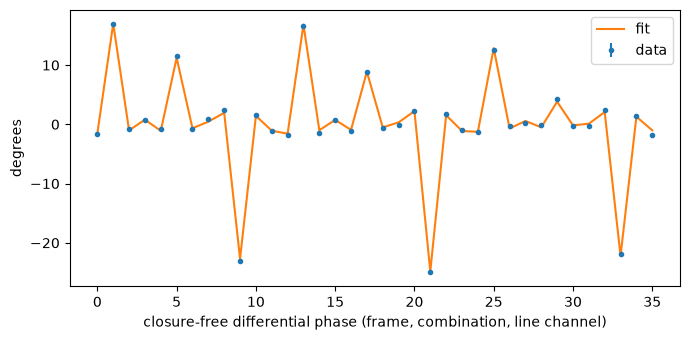

In [3]:
block = data.extras[-1]
cvis = result.model.model(data.u, data.v, data.wavel)
model = np.asarray(block.predict(result.model, cvis))
observed = np.asarray(block.data())
errors = np.asarray(block.data_errors())
fig, ax = plt.subplots(figsize=(7, 3.5))
index = np.arange(model.size)
ax.errorbar(
    index, np.rad2deg(observed), np.rad2deg(errors), fmt=".", label="data"
)
ax.plot(index, np.rad2deg(model), "-", label="fit")
ax.set_xlabel(
    "closure-free differential phase (frame, combination, line channel)"
)
ax.set_ylabel("degrees")
ax.legend()
plt.tight_layout()
plt.show()